# Sprint 11 · Webinar 34 · Data Analytics teórico  
## Simulación como herramienta estadística

**Programa:** Data Analytics  
**Sprint:** 10  
**Duración:** 100 minutos  
**Modalidad:** Teórica (con demostraciones en Python)


## Fecha
**Por definir**


## Objetivos de la sesión

Al finalizar la sesión, el/la estudiante podrá:

1. Explicar **qué es una simulación** y por qué es una herramienta poderosa en análisis de datos.
2. Generar **datos sintéticos** que respeten una estructura estadística conocida (distribuciones, efectos, relaciones).
3. Aplicar **bootstrap (remuestreo)** sobre datos reales para estimar intervalos de confianza sin fórmulas complicadas.
4. Usar **simulación de Monte Carlo** para responder preguntas de negocio sobre riesgo y probabilidad.
5. Ejecutar un **test de permutaciones** como alternativa no paramétrica al t-test que ya conocemos.
6. Combinar todas las técnicas en un **análisis integrador** para tomar una decisión de negocio.


## Agenda sugerida (100 minutos)

| Tiempo | Bloque | Contenido |
|---:|---|---|
| 0–10 | Actividad 0 | ¿Qué es simular? Intuición con dado justo vs. cargado |
| 10–25 | Ejercicio 1 | Generar datos sintéticos: un dataset realista desde cero |
| 25–45 | Ejercicio 2 | Bootstrap: intervalos de confianza sin fórmulas |
| 45–65 | Ejercicio 3 | Monte Carlo: estimar probabilidades de negocio |
| 65–85 | Ejercicio 4 | Test de permutaciones: hipótesis sin supuestos paramétricos |
| 85–100 | Integrador | Unir todas las técnicas: ¿el nuevo pricing es mejor? |


---
## Actividad 0 · Calentamiento: ¿Qué es simular? (10 min)

### ¿Qué significa "simular"?

**Simular** es generar datos artificiales usando reglas conocidas (distribuciones de probabilidad, modelos, parámetros) para:

- **Explorar** escenarios que aún no han ocurrido ("¿qué pasaría si...?").
- **Estimar** cantidades difíciles de calcular con fórmulas exactas.
- **Validar** si nuestras pruebas estadísticas funcionan correctamente con nuestros datos.

> **Analogía:** imagina que quieres saber si un dado es justo. Podrías:
> 1. Tirarlo 10,000 veces a mano y anotar cada resultado (lento, tedioso).
> 2. O pedirle a Python que "tire" el dado 10,000 veces en milisegundos.
>
> El resultado es el mismo, pero la computadora lo hace **rápido, reproducible y modificable**.

### ¿Por qué simular y no solo analizar los datos que ya tenemos?

Los datos reales son limitados: tienen un tamaño fijo, pueden tener sesgos, y no los podemos "repetir" bajo condiciones diferentes. La simulación nos da superpoderes:

- Podemos generar **miles de escenarios** para entender la variabilidad.
- Podemos **controlar la verdad**: como nosotros generamos los datos, sabemos exactamente qué efecto existe.
- Podemos **probar herramientas** antes de usarlas con datos reales.

### Técnicas de simulación que veremos hoy

| Técnica | ¿Qué hace? | ¿Para qué sirve? |
|---|---|---|
| **Datos sintéticos** | Genera datos falsos con estructura conocida | Practicar, prototipar, proteger privacidad |
| **Bootstrap** (remuestreo) | Saca muchas muestras del mismo dataset con reemplazo | Intervalos de confianza sin fórmulas |
| **Monte Carlo** | Repite un proceso aleatorio miles de veces | Estimar probabilidades, riesgo financiero |
| **Test de permutaciones** | Mezcla las etiquetas de dos grupos al azar | Probar hipótesis sin supuestos paramétricos |

### Discusión en equipos (5 min)

En parejas o equipos de 3, discutan:

1. Piensen en un negocio (e-commerce, app, banco, restaurante...) y describan **una situación** en la que les gustaría "simular" antes de tomar una decisión.
2. ¿Por qué **no basta** con mirar los datos que ya tienen?
3. ¿Qué **incertidumbre** hay en esa situación?

> **Objetivo:** entender que la simulación nos permite explorar la variabilidad y el riesgo antes de decidir.

**Recurso externo:** para visualizar distribuciones de probabilidad de forma interactiva:  
[GeoGebra – Estadística](https://www.geogebra.org/math/statistics?lang=en)  
Pueden jugar con dados, monedas y distribuciones normales para construir intuición.


### Imports y configuración

Antes de empezar, cargamos las librerías que usaremos durante toda la clase. Ejecuta esta celda primero.


In [1]:
# ============================================================
# Imports y configuración (ejecuta esta celda primero)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# Semilla global para reproducibilidad
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Librerías cargadas.")

Librerías cargadas.


### Ejemplo introductorio: dado justo vs. dado cargado

Para entender la idea, simulamos 10,000 lanzamientos de dos dados:

- **Dado justo:** cada cara (1-6) tiene la misma probabilidad: 1/6.
- **Dado cargado:** la cara 6 sale el doble de veces (probabilidad 2/7 vs. 1/7 para las demás).

Con solo ejecutar una celda, generamos los 10,000 lanzamientos y podemos comparar visualmente.


In [36]:
# Simular 10,000 lanzamientos de cada dado

n = 10_000

dado_justo = rng.integers(1, 7, size=n)  # 7 no se incluye
dado_cargado = rng.choice([1,2,3,4,5,6], size=n, p=[1/7,1/7,1/7,1/7,1/7,2/7])

### Visualizar los resultados

Comparamos las frecuencias relativas de cada cara. La línea roja marca lo que esperaríamos de un dado justo (1/6 ≈ 0.167).


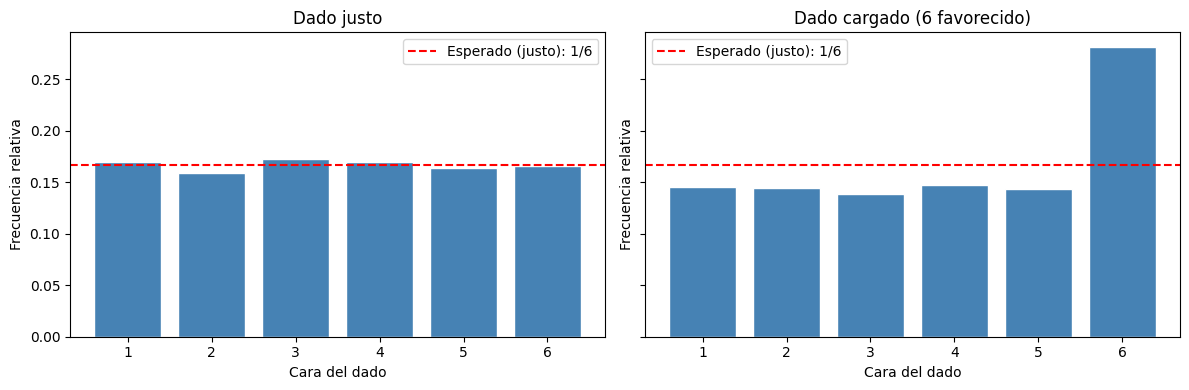

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, datos, titulo in zip(axes, 
                              [dado_justo, dado_cargado], 
                              ["Dado justo", "Dado cargado (6 favorecido)"]):
    caras, conteos = np.unique(datos, return_counts=True)
    ax.bar(caras, conteos / n, color="steelblue", edgecolor="white")
    ax.axhline(1/6, color="red", linestyle="--", label="Esperado (justo): 1/6")
    ax.set_title(titulo)
    ax.set_xlabel("Cara del dado")
    ax.set_ylabel("Frecuencia relativa")
    ax.set_xticks(range(1, 7))
    ax.legend()

plt.tight_layout()
plt.show()

> **Reflexión:** con 10,000 lanzamientos simulados pudimos detectar claramente que el dado cargado favorece al 6.  
> Esta es la idea central de toda la sesión: **usar la computadora para generar muchos datos y aprender de ellos.**  
> En la vida real no tenemos dados, pero tenemos ventas, clics, conversiones, tiempos... y podemos simularlos.


---
## Ejercicio 1 · Generar datos sintéticos realistas (15 min)

### 10.1 ¿Qué son los datos sintéticos?

Los **datos sintéticos** son datos generados por computadora que imitan la estructura y las propiedades estadísticas de datos reales, pero sin contener información real de ninguna persona o empresa.

### ¿Para qué sirven?

- **Practicar** técnicas de análisis cuando no tienes datos reales disponibles.
- **Prototipar** dashboards y reportes antes de que lleguen los datos reales.
- **Proteger privacidad:** compartir datos con estructura similar sin exponer información sensible.
- **Controlar la verdad:** como TÚ generas los datos, sabes exactamente qué efecto existe — perfecto para aprender y validar.

### 10.1.1 Distribuciones de probabilidad: la base de la simulación

Para generar datos realistas, necesitamos elegir la **distribución** correcta para cada variable. Cada distribución modela un tipo diferente de fenómeno:

| Distribución | ¿Cuándo usarla? | Ejemplo en negocio | Función en NumPy |
|---|---|---|---|
| **Normal** | Variables continuas simétricas | Ticket de compra, pesos | `rng.normal(media, std, n)` |
| **Bernoulli/Binomial** | Resultado sí/no | ¿Convirtió? ¿Hizo clic? | `rng.binomial(1, prob, n)` |
| **Poisson** | Conteos por período | Páginas vistas, tickets/día | `rng.poisson(media, n)` |
| **Exponencial** | Tiempos de espera | Minutos en el sitio, entre compras | `rng.exponential(media, n)` |
| **Uniforme** | Todo igual de probable | IDs, selección aleatoria | `rng.uniform(min, max, n)` |

> **Nota:** `rng` es nuestro generador de números aleatorios creado con `np.random.default_rng(seed)`.  
> La **semilla (seed)** garantiza que los resultados sean **reproducibles**: misma semilla = mismos datos.

### Objetivo del ejercicio

Generar un dataset de **ventas de una tienda online** con estructura controlada que usaremos en el resto de la clase.

**Caso de negocio:** la tienda está probando un nuevo modelo de pricing ("premium" vs. "estándar") y quiere saber si el modelo premium genera más ingresos.

**Efectos que vamos a "esconder" en los datos** (para validar después):
- El modelo **premium** tiene un ticket promedio ~15% mayor (~$75 vs ~$65).
- El canal **email** tiene mejor tasa de conversión (~20% vs ~12%).

### Pistas
- Usa `rng.choice()` para variables categóricas.
- Usa `np.where()` para que el ticket dependa del modelo de pricing.
- Usa `rng.binomial(1, prob)` para generar conversiones con probabilidades diferentes.


### Paso 1: Crear las variables categóricas

Empezamos definiendo las variables categóricas del dataset: modelo de pricing, canal de adquisición y dispositivo. Usamos `rng.choice()` con probabilidades para que la distribución sea realista (más tráfico mobile que tablet, por ejemplo).


In [ ]:
# Variables categóricas
n_rows = 8000
rng = np.random.default_rng(RANDOM_SEED)

In [ ]:
modelo = rng.choice(["estandar", "premium"], size=n_rows)
canal = rng.choice(["organic", "paid", "email", "social"], size=n_rows, p=[.35, .25, .25, .15])
dispositivo = rng.choice(["mobile", "desktop", "tablet"], size=n_rows, p=[.55, .35, .10])

### Paso 2: Generar el ticket de compra (variable numérica)

Aquí es donde introducimos el **efecto principal**: el modelo premium tiene un ticket promedio más alto.

Usamos `np.where()` para asignar distribuciones diferentes según el grupo:
- **Premium:** normal con media $75, desviación $25.
- **Estándar:** normal con media $65, desviación $20.

Además, ponemos un piso de $5 (no hay compras negativas).


In [5]:
# Ticket: distribución normal que DEPENDE del modelo de pricing
ticket = np.where(
    modelo == "premium",
    rng.normal(75, 25, n_rows),   # premium: media $75
    rng.normal(65, 20, n_rows)    # estándar: media $65
)
ticket = np.maximum(ticket, 5).round(2)  # piso de $5, redondear a centavos

### Paso 3: Generar la conversión (variable binaria)

La conversión es un resultado sí/no (1/0). Usamos la distribución **Bernoulli** (caso especial de binomial con 1 intento).

El **efecto del canal**: email tiene mejor conversión (~20%) vs. el resto (~12%).


In [6]:
# Conversión: Bernoulli con probabilidad que depende del canal
prob_conv = np.where(canal == "email", 0.20, 0.12)
convertido = rng.binomial(1, prob_conv)

### Paso 4: Ensamblar el DataFrame completo

Juntamos todo en un DataFrame de pandas. Además, agregamos dos variables más para practicar con otras distribuciones:
- **Páginas vistas:** Poisson (conteo de eventos por visita).
- **Tiempo en sitio:** Exponencial (tiempo de espera/permanencia).


In [7]:
# Ensamblar DataFrame
df = pd.DataFrame({
    "modelo_pricing": modelo,
    "canal": canal,
    "dispositivo": dispositivo,
    "ticket_usd": ticket,
    "convertido": convertido,
    "paginas_vistas": rng.poisson(5, n_rows),           # Poisson: media ~5
    "tiempo_min": rng.exponential(4.5, n_rows).round(1)  # Exponencial: media ~4.5 min
})

print(f"Dataset generado: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset generado: 8000 filas × 7 columnas


### Exploración rápida del dataset

Siempre que generamos o recibimos un dataset, lo primero es explorar su estructura básica.


In [8]:
df.head()

,modelo_pricing,canal,dispositivo,ticket_usd,convertido,paginas_vistas,tiempo_min
0,estandar,email,mobile,75.82,1,11,6.6
1,premium,paid,mobile,65.13,1,3,12.0
2,premium,social,mobile,31.29,0,7,7.2
3,estandar,organic,tablet,69.98,0,6,0.7
4,estandar,paid,mobile,40.16,0,3,0.6


### Tipos de variables

Verificamos que cada columna tenga el tipo correcto: categóricas como `object`, numéricas como `float64` o `int64`.


In [9]:
print("Tipos de variables:")
display(df.dtypes)

Tipos de variables:


modelo_pricing     object
canal              object
dispositivo        object
ticket_usd        float64
convertido          int64
paginas_vistas      int64
tiempo_min        float64
dtype: object

### Estadísticas descriptivas

Con `describe()` revisamos la distribución de las variables numéricas: media, desviación, mínimo, máximo y percentiles.


In [10]:
df.describe()

,ticket_usd,convertido,paginas_vistas,tiempo_min
count,8000.000000,8000.000000,8000.000000,8000.000000
mean,70.547024,0.143000,5.011750,4.565038
std,23.485572,0.350095,2.252553,4.521588
min,5.000000,0.000000,0.000000,0.000000
25%,54.320000,0.000000,3.000000,1.300000
50%,69.830000,0.000000,5.000000,3.200000
75%,85.972500,0.000000,6.000000,6.400000
max,167.060000,1.000000,14.000000,46.500000


### Verificar los efectos que "escondimos" en la generación

Como nosotros controlamos la generación, podemos verificar que los efectos están presentes. Esto es una ventaja enorme para aprender: si después aplicamos un test estadístico, **sabemos cuál debería ser la respuesta correcta**.


In [11]:
# ¿El efecto del pricing se ve?
print("Ticket promedio por modelo de pricing:")
print(df.groupby("modelo_pricing")["ticket_usd"].mean().round(2))

Ticket promedio por modelo de pricing:
modelo_pricing
estandar    65.09
premium     76.17
Name: ticket_usd, dtype: float64


### Verificar el efecto del canal

El segundo efecto que escondimos: email convierte al ~20% vs. ~12% del resto.


In [12]:
# ¿El efecto del canal se ve?
print("Tasa de conversión por canal:")
print(df.groupby("canal")["convertido"].mean().round(4))

Tasa de conversión por canal:
canal
email      0.2060
organic    0.1270
paid       0.1192
social     0.1117
Name: convertido, dtype: float64


> **Punto clave:** como NOSOTROS generamos los datos, sabemos que el efecto premium existe (media ~$75 vs ~$65) y que email convierte más (~20% vs ~12%).  
> En el resto de la clase vamos a usar **simulación** para detectar y medir estos efectos.

> **Recurso:** para explorar visualmente cómo se ven las distribuciones normal, exponencial y Poisson:  
> [Seeing Theory – Distribuciones de probabilidad (Brown University)](https://seeing-theory.brown.edu/probability-distributions/index.html)


---
## Ejercicio 2 · Bootstrap: intervalos de confianza sin fórmulas (20 min)

### 10.2 ¿Qué es el bootstrap?

El **bootstrap** es una técnica de **remuestreo** que nos permite estimar la incertidumbre de cualquier estadístico (media, mediana, diferencia, ratio...) sin necesidad de fórmulas matemáticas complejas.

En clases anteriores usamos `ttest_ind` para comparar promedios, que calcula un **intervalo de confianza (IC)** con fórmulas que asumen normalidad. Bootstrap llega al mismo resultado de una forma diferente: **usando solo los datos y la computadora**.

### 10.2.1 ¿Cómo funciona el bootstrap?

El procedimiento es sorprendentemente simple:

1. Tomas tu muestra original de tamaño *n*.
2. Sacas una nueva muestra de tamaño *n* **con reemplazo** (algunos datos se repiten, otros quedan fuera).
3. Calculas el estadístico que te interesa (ej.: la media).
4. Repites los pasos 2-3 muchas veces (ej.: 5,000 veces).
5. Los resultados forman una **distribución bootstrap** → de ahí sacas el intervalo de confianza usando percentiles.

### 10.2.2 ¿Por qué funciona?

La idea es que si tu muestra es representativa de la población, entonces **remuestrear la muestra** simula lo que pasaría si pudieras tomar muchas muestras de la población real. La variabilidad entre los remuestreos estima la variabilidad real.

### 10.2.3 ¿Cuándo usar bootstrap?

- Cuando **no quieres asumir** una distribución particular (normalidad).
- Para estadísticos **sin fórmula estándar** de IC (mediana, percentil 90, ratios...).
- Cuando la muestra es **pequeña** y las fórmulas clásicas pueden fallar.

> **Analogía:** imagina una bolsa con 100 canicas de colores. Quieres saber el % de rojas, pero solo puedes sacar un puñado.  
> Bootstrap = sacar muchos puñados (devolviendo las canicas cada vez), anotar el % de rojas en cada puñado, y ver cuánto varía.

### Objetivo del ejercicio

Usar bootstrap para estimar el **intervalo de confianza del ticket promedio** para cada modelo de pricing, y la **diferencia** entre ambos.

### Pistas
- `rng.choice(datos, size=len(datos), replace=True)` genera una muestra con reemplazo.
- Guarda cada resultado en una lista y al final convierte a array.
- `np.percentile(array, 2.5)` y `np.percentile(array, 97.5)` dan los límites del IC 95%.


### Preparar los datos para bootstrap

Extraemos los tickets de cada grupo como arrays de NumPy.


In [13]:
# Separar tickets por modelo
tickets_premium = df.loc[df["modelo_pricing"] == "premium", "ticket_usd"].values
tickets_estandar = df.loc[df["modelo_pricing"] == "estandar", "ticket_usd"].values

print(f"Premium:  n={len(tickets_premium)}, media=${tickets_premium.mean():.2f}")
print(f"Estándar: n={len(tickets_estandar)}, media=${tickets_estandar.mean():.2f}")
print(f"Diferencia observada: ${tickets_premium.mean() - tickets_estandar.mean():.2f}")

Premium:  n=3937, media=$76.17
Estándar: n=4063, media=$65.09
Diferencia observada: $11.08


### Ejecutar el bootstrap (ticket promedio premium)

Hacemos 5,000 remuestreos del grupo premium. En cada uno:
1. Sacamos una muestra con reemplazo del mismo tamaño.
2. Calculamos la media.
3. La guardamos.


In [14]:
# Bootstrap: 5,000 remuestreos de la media premium
rng_b = np.random.default_rng(RANDOM_SEED)
n_boot = 5000

medias_boot = []
for _ in range(n_boot):
    muestra = rng_b.choice(tickets_premium, size=len(tickets_premium), replace=True)
    medias_boot.append(muestra.mean())

medias_boot = np.array(medias_boot)

In [38]:
medias_boot

array([76.28559309, 76.85166116, 76.33254001, ..., 76.19375667,
       76.48297181, 75.98252477], shape=(5000,))

### Calcular el intervalo de confianza al 95%

El IC 95% se obtiene tomando los percentiles 2.5 y 97.5 de la distribución bootstrap. Esto significa que el 95% de las medias bootstrap caen dentro de este rango.


In [15]:
# IC 95%: percentiles 2.5 y 97.5
ic_inf = np.percentile(medias_boot, 2.5)
ic_sup = np.percentile(medias_boot, 97.5)

print(f"IC 95% ticket premium: [${ic_inf:.2f}, ${ic_sup:.2f}]")
print()
print(f"Interpretación: con 95% de confianza, el ticket promedio")
print(f"real del modelo premium está entre ${ic_inf:.2f} y ${ic_sup:.2f}.")

IC 95% ticket premium: [$75.39, $76.94]

Interpretación: con 95% de confianza, el ticket promedio
real del modelo premium está entre $75.39 y $76.94.


### Visualizar la distribución bootstrap

El histograma muestra cómo se distribuyen las 5,000 medias calculadas. Las líneas rojas marcan el IC 95%.


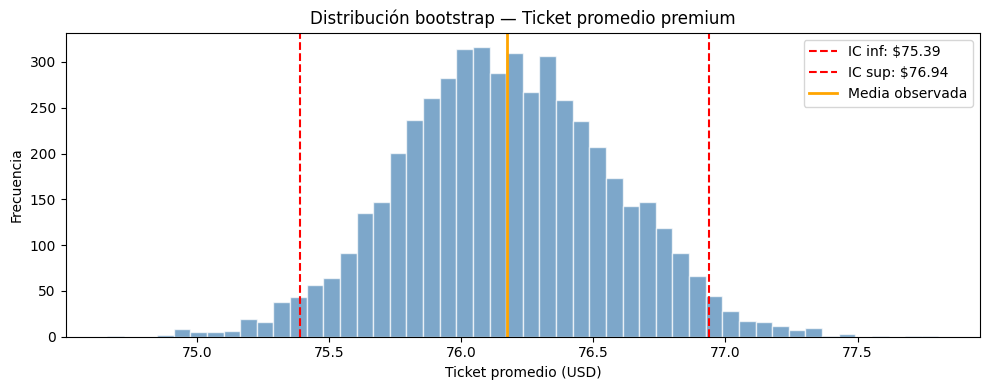

In [16]:
plt.figure(figsize=(10, 4))
plt.hist(medias_boot, bins=50, color="steelblue", edgecolor="white", alpha=0.7)
plt.axvline(ic_inf, color="red", linestyle="--", label=f"IC inf: ${ic_inf:.2f}")
plt.axvline(ic_sup, color="red", linestyle="--", label=f"IC sup: ${ic_sup:.2f}")
plt.axvline(tickets_premium.mean(), color="orange", linewidth=2, label="Media observada")
plt.title("Distribución bootstrap — Ticket promedio premium")
plt.xlabel("Ticket promedio (USD)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

### 10.2.4 Bootstrap de la DIFERENCIA de medias (la pregunta de negocio)

La pregunta real del negocio no es "¿cuál es la media de premium?" sino **"¿cuánto más paga un cliente premium vs. uno estándar?"**

Para responder esto, hacemos bootstrap de la **diferencia de medias**: en cada remuestreo, calculamos la media de cada grupo y restamos.

**Regla clave:** si el IC de la diferencia **no incluye 0**, hay evidencia de una diferencia real.


In [17]:
# Bootstrap de la diferencia (premium - estándar)
rng_b2 = np.random.default_rng(RANDOM_SEED)

diffs_boot = []
for _ in range(n_boot):
    m_p = rng_b2.choice(tickets_premium, size=len(tickets_premium), replace=True).mean()
    m_e = rng_b2.choice(tickets_estandar, size=len(tickets_estandar), replace=True).mean()
    diffs_boot.append(m_p - m_e)

diffs_boot = np.array(diffs_boot)

### Interpretar el IC de la diferencia

Si ambos límites del IC son positivos (> 0), significa que en el 95% de los remuestreos premium tuvo ticket mayor → evidencia fuerte.


In [18]:
ic_d_inf = np.percentile(diffs_boot, 2.5)
ic_d_sup = np.percentile(diffs_boot, 97.5)

print(f"IC 95% diferencia (premium − estándar): [${ic_d_inf:.2f}, ${ic_d_sup:.2f}]")
print()

if ic_d_inf > 0:
    print("→ El IC NO incluye 0: hay evidencia de que premium tiene ticket mayor.")
else:
    print("→ El IC INCLUYE 0: no podemos asegurar diferencia.")

IC 95% diferencia (premium − estándar): [$10.10, $12.07]

→ El IC NO incluye 0: hay evidencia de que premium tiene ticket mayor.


### Visualizar la diferencia bootstrap

La línea negra en 0 marca "sin diferencia". Si la distribución cae lejos del 0, hay evidencia.


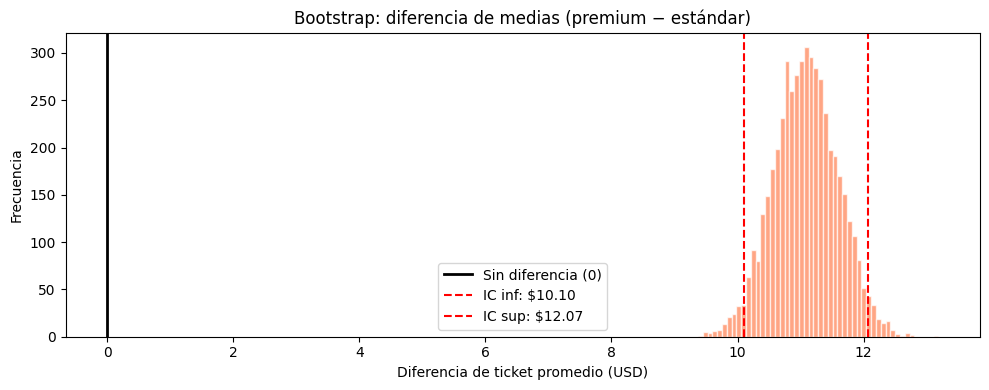

In [19]:
plt.figure(figsize=(10, 4))
plt.hist(diffs_boot, bins=50, color="coral", edgecolor="white", alpha=0.7)
plt.axvline(0, color="black", linewidth=2, label="Sin diferencia (0)")
plt.axvline(ic_d_inf, color="red", linestyle="--", label=f"IC inf: ${ic_d_inf:.2f}")
plt.axvline(ic_d_sup, color="red", linestyle="--", label=f"IC sup: ${ic_d_sup:.2f}")
plt.title("Bootstrap: diferencia de medias (premium − estándar)")
plt.xlabel("Diferencia de ticket promedio (USD)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

> **Punto clave:** el bootstrap nos dio un **rango de valores plausibles** para la diferencia entre los modelos, SIN necesitar fórmulas ni supuestos de normalidad. Solo usamos los datos y remuestreo.

> **Pregunta para discutir:** ¿Qué pasaría si en vez de ~4,000 observaciones por grupo tuviéramos solo 30?  
> (Pista: el intervalo sería mucho más ancho → más incertidumbre → menos certeza para decidir).


---
## Ejercicio 3 · Simulación de Monte Carlo: estimar probabilidades (20 min)

### 10.3 ¿Qué es Monte Carlo?

**Monte Carlo** es una familia de métodos que usan muestreo aleatorio repetido para estimar cantidades que son difíciles de calcular con fórmulas exactas.

> El nombre viene del famoso **casino de Mónaco**: el método se basa en la aleatoriedad, igual que los juegos de azar.

### 10.3.1 ¿Cómo funciona?

1. Define un **modelo** del proceso que quieres estudiar (con sus reglas y parámetros).
2. **Simula** el proceso miles de veces, cada vez con valores aleatorios.
3. **Agrega** los resultados: calcula promedios, percentiles, probabilidades.

### 10.3.2 ¿Para qué se usa en negocio?

- **Riesgo financiero:** "¿cuál es la probabilidad de que mis ingresos caigan más del 20%?"
- **Inventario:** "¿cuántas unidades necesito en stock para cubrir el 95% de los escenarios de demanda?"
- **Proyecciones:** "dado lo que sé de visitas, conversión y ticket, ¿cuál es el rango probable de ingresos mensuales?"
- **Escenarios:** "¿qué pasa si lanzo una campaña que sube las visitas un 30%?"

### 10.3.3 Diferencia con bootstrap

- **Bootstrap:** remuestrea datos **existentes** para medir incertidumbre.
- **Monte Carlo:** genera datos **nuevos** a partir de un modelo para simular escenarios.

### Objetivo del ejercicio

Simular los **ingresos mensuales** de la tienda online y responder:  
*¿Cuál es la probabilidad de que los ingresos mensuales superen $90,000?*

### Modelo del proceso

```
Ingreso mensual = Σ (para cada día del mes):
    1. Llegan X visitas (Poisson)
    2. Cada visita convierte con probabilidad p (Binomial)
    3. Cada conversión genera un ticket aleatorio (Normal)
    4. Ingreso del día = suma de tickets
```

### Pistas
- Estima los parámetros (tasa de conversión, ticket medio) **desde los datos**.
- En cada simulación, cada componente varía aleatoriamente → eso captura la incertidumbre.


### Paso 1: Estimar los parámetros desde nuestro dataset

Usamos los datos sintéticos para definir los parámetros del modelo. En un caso real, estos vendrían de datos históricos.


In [20]:
# Parámetros estimados de nuestros datos
tasa_conv = df["convertido"].mean()
ticket_medio = df["ticket_usd"].mean()
ticket_std = df["ticket_usd"].std()

print(f"Tasa de conversión: {tasa_conv:.3f} ({tasa_conv*100:.1f}%)")
print(f"Ticket medio:       ${ticket_medio:.2f}")
print(f"Ticket desv. est.:  ${ticket_std:.2f}")
print(f"Visitas diarias:    150 (supuesto del negocio)")

Tasa de conversión: 0.143 (14.3%)
Ticket medio:       $70.55
Ticket desv. est.:  $23.49
Visitas diarias:    150 (supuesto del negocio)


### Paso 2: Ejecutar la simulación Monte Carlo

Simulamos 10,000 meses. En cada simulación:
- Generamos las visitas de 30 días con Poisson.
- Calculamos cuántas convierten con Binomial.
- Generamos el ticket de cada conversión con Normal.
- Sumamos todo = ingreso del mes.


In [21]:
# Simulación Monte Carlo: 10,000 meses
n_sim = 10_000
dias = 30
visitas_dia = 150
rng_mc = np.random.default_rng(RANDOM_SEED)

ingresos_mensuales = np.zeros(n_sim)

for i in range(n_sim):
    visitas_mes = rng_mc.poisson(visitas_dia, size=dias).sum()
    conversiones = rng_mc.binomial(visitas_mes, tasa_conv)
    tickets = rng_mc.normal(ticket_medio, ticket_std, size=conversiones)
    tickets = np.maximum(tickets, 5)  # piso de $5
    ingresos_mensuales[i] = tickets.sum()

print(f"Simulación completa: {n_sim} meses simulados")
print(f"Ingreso mensual promedio: ${ingresos_mensuales.mean():,.0f}")
print(f"Ingreso mensual mediana:  ${np.median(ingresos_mensuales):,.0f}")

Simulación completa: 10000 meses simulados
Ingreso mensual promedio: $45,399
Ingreso mensual mediana:  $45,389


### Paso 3: Responder la pregunta de negocio

Ahora usamos los 10,000 resultados para responder preguntas concretas:
- ¿Cuál es la probabilidad de superar la meta?
- ¿Cuáles son los escenarios pesimista, esperado y optimista?


In [22]:
# Probabilidad de superar la meta
meta = 90_000
prob_meta = (ingresos_mensuales >= meta).mean()

print(f"¿Probabilidad de superar ${meta:,}? → {prob_meta:.1%}")
print()

# Escenarios por percentiles
print("Escenarios de ingreso mensual:")
for p in [5, 25, 50, 75, 95]:
    print(f"  Percentil {p:3d}: ${np.percentile(ingresos_mensuales, p):>10,.0f}")
print()
print(f"Peor 5% de los meses: ingreso < ${np.percentile(ingresos_mensuales, 5):,.0f}")
print(f"Mejor 5%:             ingreso > ${np.percentile(ingresos_mensuales, 95):,.0f}")

¿Probabilidad de superar $90,000? → 0.0%

Escenarios de ingreso mensual:
  Percentil   5: $    42,319
  Percentil  25: $    44,120
  Percentil  50: $    45,389
  Percentil  75: $    46,696
  Percentil  95: $    48,540

Peor 5% de los meses: ingreso < $42,319
Mejor 5%:             ingreso > $48,540


### Visualizar los resultados

Dos gráficos complementarios:
- **Histograma:** muestra la distribución de ingresos y dónde cae la meta.
- **CDF (distribución acumulada):** permite leer directamente la probabilidad de cualquier valor.


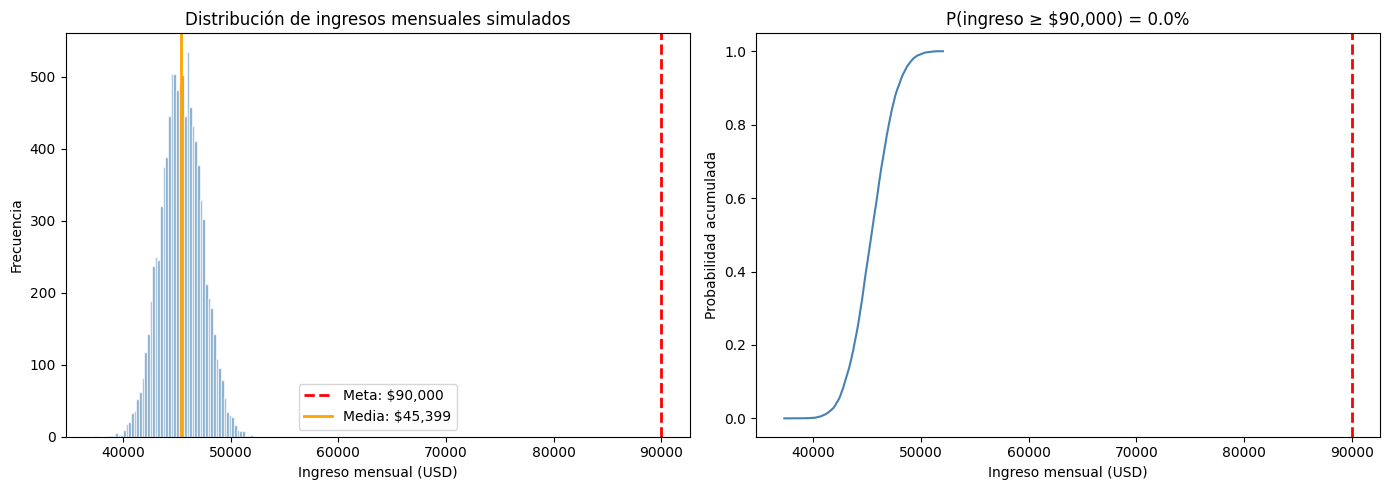

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(ingresos_mensuales, bins=60, color="steelblue", edgecolor="white", alpha=0.7)
axes[0].axvline(meta, color="red", linestyle="--", linewidth=2, label=f"Meta: ${meta:,}")
axes[0].axvline(ingresos_mensuales.mean(), color="orange", linewidth=2, label=f"Media: ${ingresos_mensuales.mean():,.0f}")
axes[0].set_xlabel("Ingreso mensual (USD)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de ingresos mensuales simulados")
axes[0].legend()

# CDF
x_sorted = np.sort(ingresos_mensuales)
cdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
axes[1].plot(x_sorted, cdf, color="steelblue")
axes[1].axvline(meta, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Ingreso mensual (USD)")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].set_title(f"P(ingreso ≥ ${meta:,}) = {prob_meta:.1%}")

plt.tight_layout()
plt.show()

> **Punto clave:** Monte Carlo nos permitió responder una pregunta compleja de negocio sin fórmulas cerradas.  
> Solo necesitamos: (1) un modelo del proceso, (2) distribuciones razonables para cada componente, (3) muchas repeticiones.

> **Pregunta para discutir:** ¿Qué parámetro cambiarías si quisieras simular el efecto de una nueva campaña de marketing que aumenta las visitas diarias en un 30%?  
> (Pista: solo cambia `visitas_dia` de 150 a 195 y vuelve a correr la simulación).


---
## Ejercicio 4 · Test de permutaciones: hipótesis sin supuestos (20 min)

### 10.4 ¿Qué es un test de permutaciones?

En la clase anterior aprendimos a usar `ttest_ind` de SciPy para comparar dos grupos. El t-test funciona bien, pero **asume que los datos siguen una distribución normal** (o que la muestra es lo suficientemente grande).

El **test de permutaciones** es una alternativa que **no asume ninguna distribución**. Es una prueba de hipótesis que usa simulación para construir su propia distribución de referencia.

### 10.4.1 La idea central

Si **no hubiera diferencia real** entre los grupos, entonces las etiquetas ("premium", "estándar") no importarían. Podríamos mezclarlas al azar y la diferencia de medias sería similar.

Entonces:
1. Calculamos la **diferencia observada** entre los grupos reales.
2. **Mezclamos** (permutamos) las etiquetas al azar: asignamos aleatoriamente quién es "premium" y quién es "estándar".
3. Calculamos la diferencia con las etiquetas mezcladas.
4. Repetimos 2-3 unas 10,000 veces.
5. **p-value** = fracción de veces que la diferencia permutada fue tan extrema como la observada.

### 10.4.2 ¿Cuándo usar permutaciones vs. t-test?

| Situación | Mejor opción |
|---|---|
| Muestra grande (n > 100), datos simétricos | t-test (más rápido, misma conclusión) |
| Muestra pequeña (n < 30) | Permutaciones (no necesita normalidad) |
| Datos con outliers extremos o asimétricos | Permutaciones (más robusto) |
| Estadístico que no es la media (mediana, ratio) | Permutaciones (el t-test solo sirve para medias) |
| Quieres verificar que el t-test no te engaña | Corre ambos y compara |

### 10.4.3 Conexión con lo que ya sabemos

En la clase anterior usamos:
```python
t_stat, p_value = stats.ttest_ind(grupo_a, grupo_b)
```

El t-test calcula el p-value con una **fórmula** basada en la distribución t de Student.  
El test de permutaciones calcula el p-value **contando** cuántas mezclas aleatorias dan un resultado tan extremo.

**Ambos responden la misma pregunta:** *"¿la diferencia que vemos es real o podría ser puro azar?"*

### Objetivo del ejercicio

Determinar si la diferencia de ticket promedio entre premium y estándar es **estadísticamente significativa**, usando permutaciones y comparando con el t-test.

### Pistas
- `rng.permutation(array)` devuelve el array con los elementos mezclados al azar.
- El p-value bilateral cuenta los casos donde `|diferencia_permutada| >= |diferencia_observada|`.

**Recurso:** [Seeing Theory – Inferencia frecuentista](https://seeing-theory.brown.edu/frequentist-inference/index.html) para una explicación visual interactiva.


### Paso 1: Calcular la diferencia observada

Antes de permutar, necesitamos saber cuál es la diferencia "real" que queremos evaluar.


In [24]:
# Diferencia observada entre los grupos
diff_obs = tickets_premium.mean() - tickets_estandar.mean()

print(f"Media premium:  ${tickets_premium.mean():.2f}  (n={len(tickets_premium)})")
print(f"Media estándar: ${tickets_estandar.mean():.2f}  (n={len(tickets_estandar)})")
print(f"Diferencia observada: ${diff_obs:.2f}")

Media premium:  $76.17  (n=3937)
Media estándar: $65.09  (n=4063)
Diferencia observada: $11.08


### Paso 2: Ejecutar las permutaciones

Juntamos todos los tickets en un solo array, los mezclamos, y dividimos en dos grupos del mismo tamaño que los originales. La diferencia de medias de cada mezcla es lo que esperaríamos **si no hubiera efecto**.


In [25]:
# Juntar todos los tickets
todos = np.concatenate([tickets_premium, tickets_estandar])
n_prem = len(tickets_premium)

# 10,000 permutaciones
n_perm = 10_000
rng_p = np.random.default_rng(RANDOM_SEED)

diffs_perm = []
for _ in range(n_perm):
    mezclado = rng_p.permutation(todos)                  # mezclar etiquetas
    d = mezclado[:n_prem].mean() - mezclado[n_prem:].mean()  # diferencia con etiquetas mezcladas
    diffs_perm.append(d)

diffs_perm = np.array(diffs_perm)
print(f"Permutaciones completadas: {n_perm}")

Permutaciones completadas: 10000


### Paso 3: Calcular e interpretar el p-value

El p-value es la proporción de permutaciones donde la diferencia (en valor absoluto) fue **al menos tan grande** como la que observamos. Si es muy bajo (< 0.05), la diferencia observada es difícil de explicar por azar.


In [26]:
# p-value bilateral
p_perm = (np.abs(diffs_perm) >= np.abs(diff_obs)).mean()

print(f"Diferencia observada: ${diff_obs:.2f}")
print(f"p-value (permutaciones): {p_perm:.6f}")
print()

alpha = 0.05
if p_perm < alpha:
    print(f"Con α={alpha}: RECHAZAR H0 → la diferencia es estadísticamente significativa.")
else:
    print(f"Con α={alpha}: NO rechazar H0 → evidencia insuficiente.")

Diferencia observada: $11.08
p-value (permutaciones): 0.000000

Con α=0.05: RECHAZAR H0 → la diferencia es estadísticamente significativa.


### Paso 4: Comparar con el t-test clásico

Corremos `ttest_ind` (que ya conocemos) para ver si ambos métodos llegan a la misma conclusión.


In [27]:
# t-test clásico (lo vimos en la clase anterior)
t_stat, p_ttest = stats.ttest_ind(tickets_premium, tickets_estandar)

print("Comparación de métodos:")
print(f"  Permutaciones → p = {p_perm:.6f}")
print(f"  t-test        → p = {p_ttest:.6f}  (t-stat = {t_stat:.2f})")
print()
print("Con muestra grande y datos ~normales, las conclusiones son similares.")
print("La ventaja de permutaciones se nota con muestras chicas o datos no normales.")

Comparación de métodos:
  Permutaciones → p = 0.000000
  t-test        → p = 0.000000  (t-stat = 21.71)

Con muestra grande y datos ~normales, las conclusiones son similares.
La ventaja de permutaciones se nota con muestras chicas o datos no normales.


### Visualizar el test de permutaciones

El histograma gris muestra la distribución de diferencias **bajo H0** (si no hubiera efecto). La línea roja muestra nuestra diferencia observada. Si la línea roja cae en una zona donde casi ninguna permutación llega, es evidencia de un efecto real.


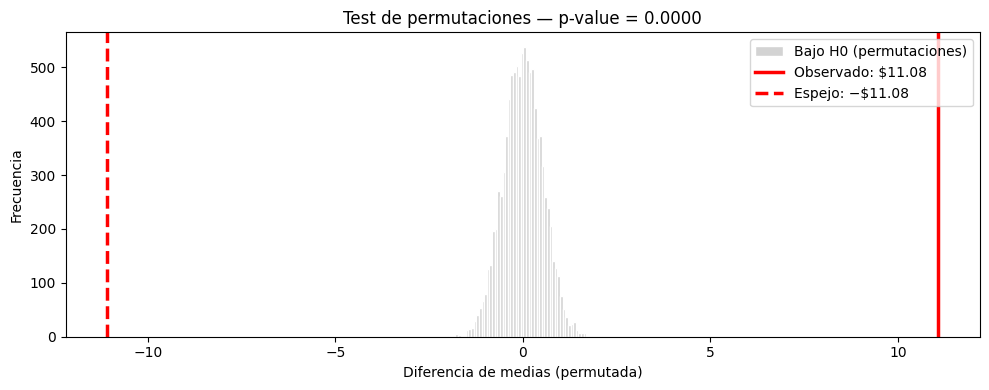

In [28]:
plt.figure(figsize=(10, 4))
plt.hist(diffs_perm, bins=60, color="lightgray", edgecolor="white", label="Bajo H0 (permutaciones)")
plt.axvline(diff_obs, color="red", linewidth=2.5, label=f"Observado: ${diff_obs:.2f}")
plt.axvline(-diff_obs, color="red", linewidth=2.5, linestyle="--", label=f"Espejo: −${diff_obs:.2f}")
plt.title(f"Test de permutaciones — p-value = {p_perm:.4f}")
plt.xlabel("Diferencia de medias (permutada)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

> **Punto clave:** el test de permutaciones construye su propia distribución de referencia "bajo H0" al mezclar las etiquetas.  
> No necesita asumir normalidad ni varianzas iguales.  
> Es como preguntarse: *"si premium y estándar fueran lo mismo, ¿sería fácil ver una diferencia así de grande por azar?"*

> **Nota importante:** el test de permutaciones y el t-test responden la **misma pregunta** pero usando caminos diferentes. Con datos "bien portados" y muestras grandes, dan resultados casi idénticos. Las permutaciones brillan cuando los datos son raros (asimétricos, con outliers, muestras chicas).


---
## Integrador · ¿El nuevo pricing es mejor? (15 min)

### 10.5 Unir todas las técnicas en una decisión de negocio

El equipo de producto pregunta: **¿el modelo de pricing premium genera más ingresos totales?**

Solo mirar el ticket promedio no basta — también importa cuánta gente convierte. Un ticket alto no sirve si nadie compra.

### Métrica clave: Revenue Per Visit (RPV)

El **RPV** (ingreso por visita) combina ambos factores:

$$\text{RPV} = \text{tasa de conversión} \times \text{ticket promedio}$$

En la práctica, lo calculamos por visita: si convirtió, su RPV es el ticket; si no convirtió, su RPV es $0.

### Plan de análisis

Vamos a aplicar las **3 técnicas de simulación** que aprendimos hoy:

1. **Bootstrap** → IC de la diferencia de RPV.
2. **Permutaciones** → p-value de la diferencia de RPV.
3. **Monte Carlo** → ¿qué probabilidad hay de que premium genere más ingreso mensual?


### Paso 1: Calcular el RPV observado

Para cada visita: si convirtió, RPV = ticket; si no convirtió, RPV = $0.


In [29]:
# RPV = ingreso que genera cada visita
df["rpv"] = df["ticket_usd"] * df["convertido"]

rpv_p = df.loc[df["modelo_pricing"] == "premium", "rpv"].values
rpv_e = df.loc[df["modelo_pricing"] == "estandar", "rpv"].values

print(f"RPV Premium:  ${rpv_p.mean():.2f}")
print(f"RPV Estándar: ${rpv_e.mean():.2f}")
print(f"Diferencia:   ${rpv_p.mean() - rpv_e.mean():.2f}")

RPV Premium:  $10.73
RPV Estándar: $9.45
Diferencia:   $1.29


### Paso 2: Bootstrap del RPV

¿Cuál es el rango plausible de la diferencia de RPV?


In [30]:
# Bootstrap de la diferencia de RPV
rng_i = np.random.default_rng(RANDOM_SEED)

diffs_rpv_boot = []
for _ in range(5000):
    d = (rng_i.choice(rpv_p, len(rpv_p), replace=True).mean() - 
         rng_i.choice(rpv_e, len(rpv_e), replace=True).mean())
    diffs_rpv_boot.append(d)

diffs_rpv_boot = np.array(diffs_rpv_boot)
print(f"IC 95% diferencia RPV: [${np.percentile(diffs_rpv_boot, 2.5):.2f}, ${np.percentile(diffs_rpv_boot, 97.5):.2f}]")

IC 95% diferencia RPV: [$0.10, $2.46]


### Paso 3: Test de permutaciones sobre RPV

¿La diferencia de RPV es estadísticamente significativa?


In [31]:
# Permutaciones sobre RPV
todos_rpv = np.concatenate([rpv_p, rpv_e])
diff_rpv_obs = rpv_p.mean() - rpv_e.mean()

rng_i2 = np.random.default_rng(RANDOM_SEED)
diffs_rpv_perm = []
for _ in range(10_000):
    m = rng_i2.permutation(todos_rpv)
    diffs_rpv_perm.append(m[:len(rpv_p)].mean() - m[len(rpv_p):].mean())

p_rpv = (np.abs(diffs_rpv_perm) >= np.abs(diff_rpv_obs)).mean()
print(f"p-value permutaciones RPV: {p_rpv:.6f}")

p-value permutaciones RPV: 0.026800


### Paso 4: Monte Carlo — proyección mensual por modelo

¿Qué probabilidad hay de que premium genere más ingresos en un mes cualquiera?


In [32]:
# Monte Carlo comparativo: 5,000 meses para cada modelo
rng_i3 = np.random.default_rng(RANDOM_SEED)

ing_prem = np.zeros(5000)
ing_est = np.zeros(5000)

for i in range(5000):
    vis = rng_i3.poisson(150, size=30).sum()  # visitas del mes
    ing_prem[i] = rng_i3.choice(rpv_p, size=vis, replace=True).sum()
    ing_est[i] = rng_i3.choice(rpv_e, size=vis, replace=True).sum()

prob_prem_gana = (ing_prem > ing_est).mean()
print(f"P(Premium > Estándar en un mes): {prob_prem_gana:.1%}")
print(f"Ingreso mensual Premium:  ${ing_prem.mean():,.0f}")
print(f"Ingreso mensual Estándar: ${ing_est.mean():,.0f}")

P(Premium > Estándar en un mes): 99.0%
Ingreso mensual Premium:  $48,304
Ingreso mensual Estándar: $42,513


### Paso 5: Resumen visual ejecutivo

Tres gráficos que resumen todo el análisis para presentar al equipo de producto.


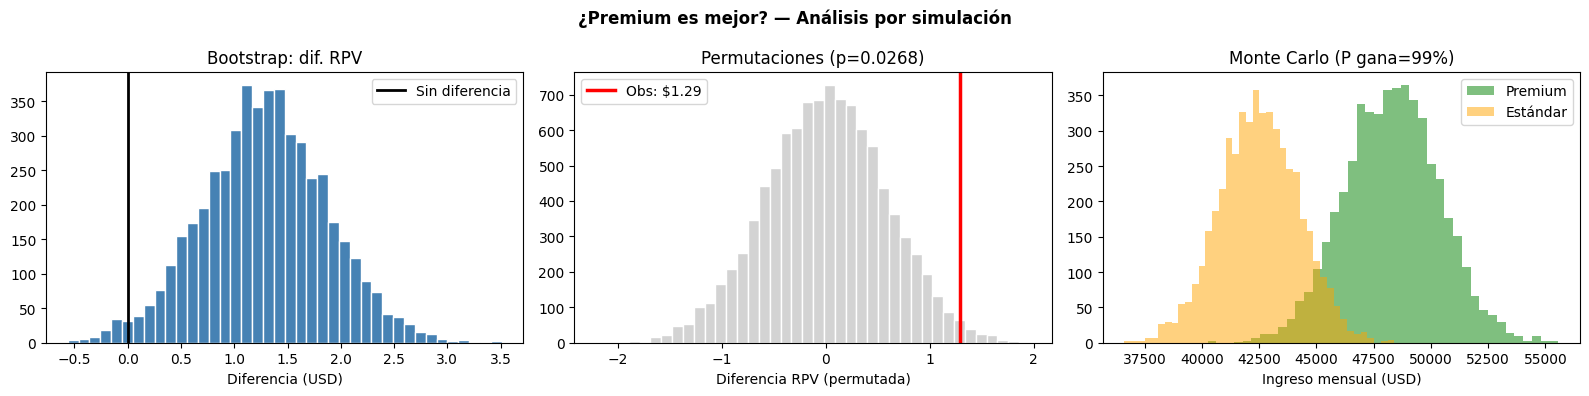

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Bootstrap: diferencia de RPV
axes[0].hist(diffs_rpv_boot, bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=2, label="Sin diferencia")
axes[0].set_title("Bootstrap: dif. RPV")
axes[0].set_xlabel("Diferencia (USD)")
axes[0].legend()

# 2. Permutaciones: distribución bajo H0
axes[1].hist(diffs_rpv_perm, bins=40, color="lightgray", edgecolor="white")
axes[1].axvline(diff_rpv_obs, color="red", linewidth=2.5, label=f"Obs: ${diff_rpv_obs:.2f}")
axes[1].set_title(f"Permutaciones (p={p_rpv:.4f})")
axes[1].set_xlabel("Diferencia RPV (permutada)")
axes[1].legend()

# 3. Monte Carlo: distribución de ingresos
axes[2].hist(ing_prem, bins=40, alpha=0.5, color="green", label="Premium")
axes[2].hist(ing_est, bins=40, alpha=0.5, color="orange", label="Estándar")
axes[2].set_title(f"Monte Carlo (P gana={prob_prem_gana:.0%})")
axes[2].set_xlabel("Ingreso mensual (USD)")
axes[2].legend()

plt.suptitle("¿Premium es mejor? — Análisis por simulación", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Takeaways (5 min)

1. **Simular** = generar datos con reglas conocidas para explorar, estimar y validar.
2. **Datos sintéticos:** control total sobre los efectos — sabemos "la verdad", perfecto para aprender y prototipar.
3. **Bootstrap:** da intervalos de confianza para **cualquier estadístico**, sin fórmulas ni supuestos de distribución. Solo necesita remuestreo con reemplazo.
4. **Monte Carlo:** responde preguntas complejas de negocio (probabilidades, riesgo, escenarios) simulando el proceso completo muchas veces.
5. **Test de permutaciones:** alternativa al t-test que **no asume distribución** — construye su propia distribución "bajo H0" mezclando etiquetas.
6. En la práctica, estas técnicas se **combinan**: generas datos → bootstrapeas → simulas escenarios → validas con permutaciones.
7. Todas las técnicas comparten la misma lógica: **repetir un proceso aleatorio muchas veces y analizar los resultados**.


## Cierre y próximos pasos

Temas que se pueden explorar después de esta sesión:
- **Validación cruzada:** otra forma de remuestreo, usada en machine learning para evaluar modelos.
- **Simulación de series temporales:** agregar tendencia, estacionalidad y ruido.
- **Optimización por simulación:** encontrar el mejor precio, inventario óptimo, staffing ideal.
- **Bayesian bootstrap:** variante con pesos aleatorios en vez de remuestreo directo.

### Recursos para profundizar

- [GeoGebra – Estadística interactiva](https://www.geogebra.org/math/statistics?lang=en): visualizar distribuciones y muestras de forma interactiva.
- [Seeing Theory (Brown University)](https://seeing-theory.brown.edu/): visualizaciones interactivas de probabilidad, distribuciones e inferencia.
- [Statistics by Jim – Bootstrapping](https://statisticsbyjim.com/hypothesis-testing/bootstrapping/): explicación clara de bootstrap con ejemplos prácticos.

### Pregunta final

Si el equipo de finanzas pregunta *"¿cuánto podríamos perder si la tasa de conversión cae un 20% el próximo trimestre?"*, ¿qué técnica de simulación usarías y por qué?
